INTRODUCCION

En este trabajo se analiza el contenido espectral de distintos tipos de señales mediante la Transformada Rápida de Fourier (FFT) en Python. Se generaron señales senoidales, ruido (normal y uniforme), una señal rectangular y un pulso gaussiano. De estas señales se analizó su comportamiento tanto en el dominio temporal como su magnitud en el dominio de frecuancia. 

En primer lugar se importaron las librerías necesarias y se definieron las variables. Por enunciado se pedían señales de $N = 1000$ muestras y senoidales de $f = 2\text{ kHz}$. A su vez se pedía que haya al menos 10 muestras por período, por lo cual:

$$10\left(\frac{1}{f_s}\right) \ge \frac{1}{f}$$

Lo cual implica:

$$f_s \ge 10f$$

Sin embargo, se eligió $f_s = 50\text{ kHz}$ ya que en los límites inferiores para $f_s$ el tiempo para el cual se visualiza la señal es mayor. Siendo la frecuencia de la señal $2\text{ kHz}$, si por ejemplo se eligiese una $f_s$ de $20\text{ kHz}$ (caso límite para que haya al menos 10 muestras por período), la ventana temporal de muestreo sería de $50\text{ ms}$, por lo cual se verían 100 ciclos superpuestos. En cambio, al elegir una $f_s$ mayor como $50\text{ kHz}$, la ventana temporal se acorta a $20\text{ ms}$, observándose 40 ciclos de la senoidal. 

Sin embargo, también hay que considerar que la resolución espectral, es decir, la mínima separación entre frecuencias que puede distinguir la DFT, es $\frac{f_s}{N}$. Por lo cual, al aumentar $f_s$ se empeora la resolución en frecuencia. 

Con esto se definió el vector de tiempo y frecuencia. Para el caso del vector temporal se definió un vector de $N$ puntos separados por:

$$T_s = \frac{1}{f_s}$$

Por otro lado, para el vector de frecuencias, como la FFT de la mitad de frecuencias negativas es un "espejo" de la positiva, se definió el vector hasta $\frac{N}{2}$ y luego se lo multiplicó por la resolución espectral.


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal


In [6]:
# DEFINICION DE VARIABLES
N=1000 #muestras

#1.
f=2000 #hz
vmax1=1
#como me pide al menos 10 puntos por periodo-> 10(1/fs)>=1/f -> fs>=10f
fs= 50000 #hz

#vector tiempo
n=np.arange(0, stop=N/fs, step=1/fs)
#vector de frecuencias
fftx=np.arange(N//2)*fs/N

#2.
PM = 2 #wats
#como P=Vmax**2/2 ->Vmax=raiz(P*2)
vmax2= np.sqrt(PM*2)
ph= np.pi/2

#3. y 4.
dc= 0 #volt
var=0.1 #wats
#para que en la distribuicion uniforme la media sea 0->a+b=0
# y para que la varianza sea 0.1-> raiz(0.1*12)=b-a
#despejando: a= -raz(1.2)/2  y b= raz(1.2)/2
a=-np.sqrt(1.2)/2
b=np.sqrt(1.2)/2

#5.
P=1#WATS
amp = np.sqrt(P)
cicloact= 0.5 


Luego se definieron las señales pedidas por el enunciado:

In [13]:
# SEÑALES
xseno1= vmax1*np.sin(2*np.pi*f*n)
xseno2= vmax2*np.sin(2*np.pi*f*n + ph)
ruidonormal=np.random.normal(loc=dc, scale=np.sqrt(var), size=N)
ruidouniforme=np.random.uniform(low=a, high= b, size=N)
rectangular= amp*signal.square(2*np.pi*f*n, duty=cicloact)
#gaussiana
centro = 0.005
gaussianareal, gaussianaimaginaria, gaussiana = signal.gausspulse(n-centro, f, retquad=True, retenv=True)


Con estas señales, usando la función fft de NumPy se obtuvieron los vectores correspondientes a la mitad de frecuencias positivas de la FFT para cada una de las señales. Estas se normalizaron con respecto a la cantidad total de muestras, ya que la FFT 

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j\frac{2\pi k n}{N}}$$

para una senoidal da como resultado dos picos de magnitud $\frac{N \cdot A}{2}$ en +f y -f. Por esto, al normalizarlo por N se observan picos de $\frac{A}{2}$.

En el caso de la señal cuadrada, al tratarse de una función impar, si se realiza el desarrollo de la serie de Fourier tan solo tendrá coeficientes 

$$b_k = \frac{2A}{k\pi} \cdot [1 - \cos(k\pi)]$$

donde además el término con el coseno valdrá 1 en caso de k par y -1 para los k impares. Por lo cual, para los k pares se anulan y para los k impares valdrá $\frac{4A}{k\pi}$. Es decir, se cancelan los armónicos pares y la amplitud de los impares decrece inversamente proporcional a k.

Para los ruidos normal y uniforme, al no ser señales periódicas, su FFT no concentra energía en una frecuencia puntual sino que la distribuye de forma aproximadamente pareja en todo el rango. 

Por su parte, la señal gaussiana se puede dividir en su envolvente y sus partes real e imaginaria. Para la envolvente se puede observar que su FFT es otra gaussiana centrada en 0Hz. En cambio, su parte real e imaginaria, al ser modulaciones de la envolvente por un coseno y un seno respectivamente, presentan una FFT con un pico en $f = 2000\text{ Hz}$, que coincide con la frecuencia de la gaussiana.

Luego, para calcular la magnitud se tomó el valor absoluto y también se la calculó en escala dB, para poder ver componentes de magnitudes muy distintas en un mismo gráfico.


In [37]:
# TRANSFORMADAS

# genero la fft para la senoidal 1

ffty=np.fft.fft(xseno1)[:N//2]

S1 = ffty / N
magsen1 = np.abs(S1)
magsen1_db= 10*np.log10(magsen1**2)

# genero la fft para la senoidal 1

fftseno2=np.fft.fft(xseno2)[:N//2]

S2 = fftseno2 / N
magsen2 = np.abs(S2)
magsen2_db= 10*np.log10(magsen2**2)

# genero la fft para el ruido normal

fftrn=np.fft.fft(ruidonormal)[:N//2]

RN = fftrn / N
magrn = np.abs(RN)
magrn_db= 10*np.log10(magrn**2)

# genero la fft para el ruido uniforme

fftru=np.fft.fft(ruidouniforme)[:N//2]

RU = fftru / N
magru = np.abs(RU)
magru_db= 10*np.log10(magru**2)

# genero la fft para la cuadrada

fftsq=np.fft.fft(rectangular)[:N//2]

SQ = fftsq / N
magsq = np.abs(SQ)
magsq_db= 10*np.log10(magsq**2)

# genero la fft para la gaussiana
#parte real
fftgr= np.fft.fft(gaussianareal)[:N//2]
GR = fftgr/N
maggr= np.abs(GR)
maggr_db= 10*np.log10(maggr**2)

#parte imaginaria
fftgi= np.fft.fft(gaussianaimaginaria)[:N//2]
GI = fftgi/N
maggi=np.abs(GI)
maggi_db= 10*np.log10(maggi**2)

#campana
fftxg = np.fft.fftfreq(N, d=1/fs)#uso todas las frecuencias muestreadas para ver la campana centrada en 0kHz
fftg= np.fft.fft(gaussiana)
G = fftg/N
magg=np.abs(G)
magg_db= 10*np.log10(magg**2)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12244\1559945279.py:41: RuntimeWarning: divide by zero encountered in log10
  magsq_db= 10*np.log10(magsq**2)


A partir de esto se realizaron los graficos para cada señal, tanto para la eñal original ( e el dominio temporal), como para la señal transformada (en el dominio de frecuencia)

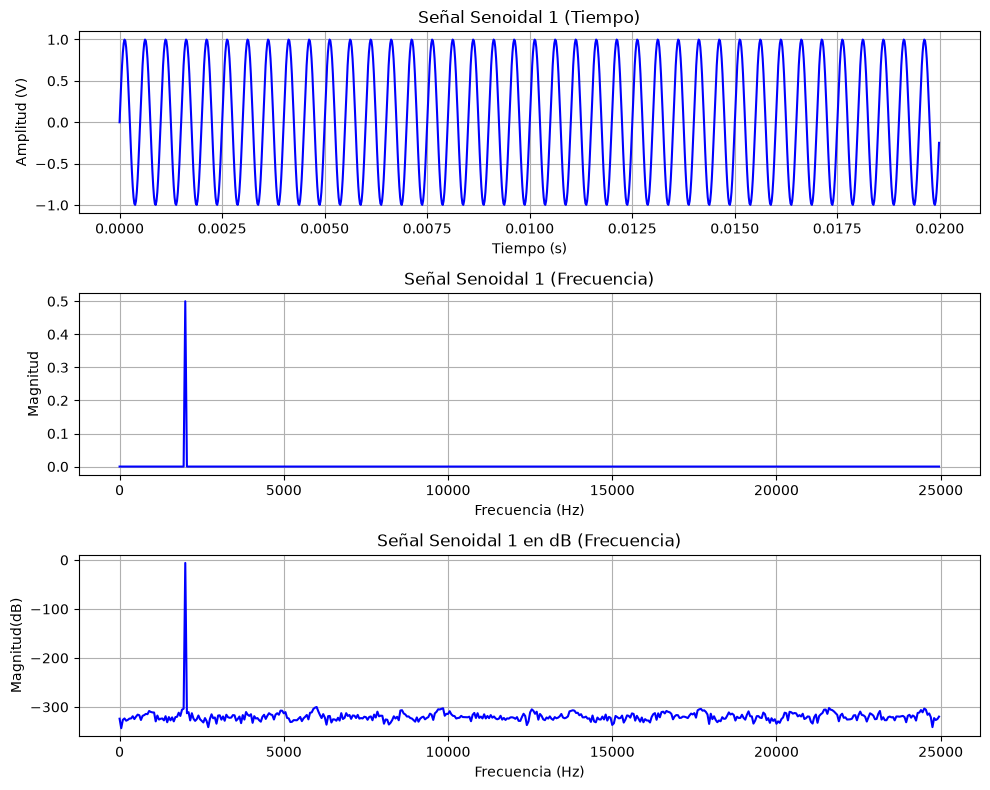

In [38]:
# GRÁFICOS
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(n, xseno1, color="blue")
ax[0].set_title("Señal Senoidal 1 (Tiempo)")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Amplitud (V)")
ax[0].grid(True)

ax[1].plot(fftx, magsen1, color="blue")
ax[1].set_title("Señal Senoidal 1 (Frecuencia)")
ax[1].set_xlabel("Frecuencia (Hz)")
ax[1].set_ylabel("Magnitud")
ax[1].grid(True)

ax[2].plot(fftx, magsen1_db, color="blue")
ax[2].set_title("Señal Senoidal 1 en dB (Frecuencia)")
ax[2].set_xlabel("Frecuencia (Hz)")
ax[2].set_ylabel("Magnitud(dB)")
ax[2].grid(True)
plt.tight_layout()
plt.show()




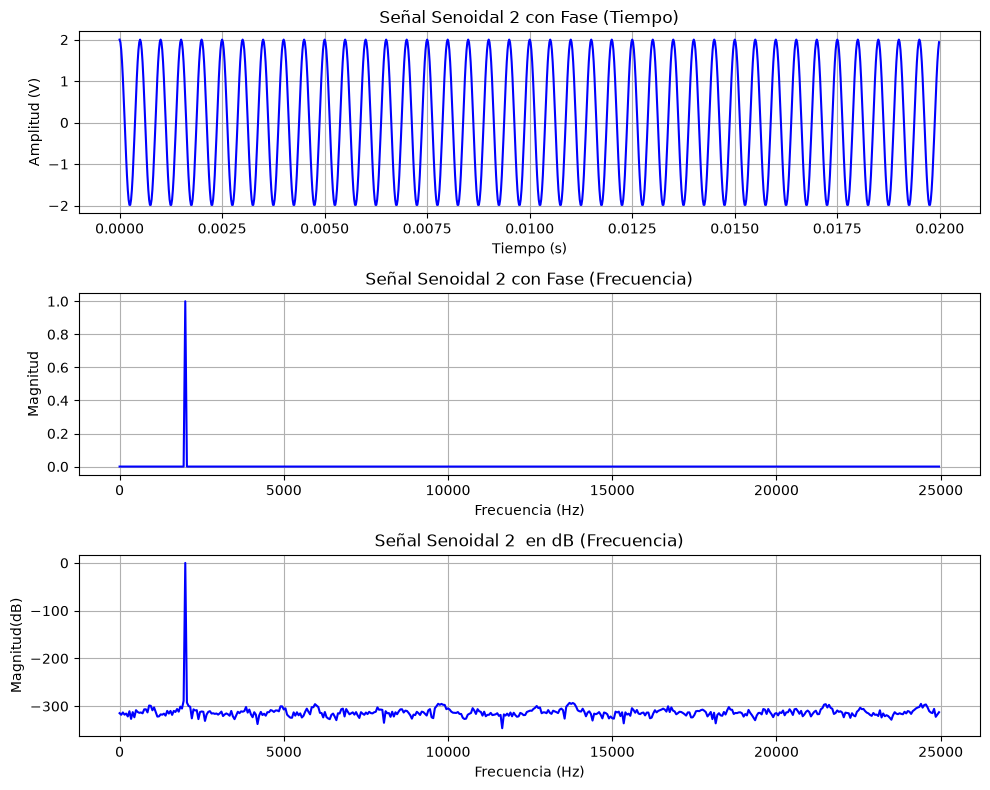

In [39]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(n, xseno2, color="blue")
ax[0].set_title("Señal Senoidal 2 con Fase (Tiempo)")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Amplitud (V)")
ax[0].grid(True)

ax[1].plot(fftx, magsen2, color="blue")
ax[1].set_title("Señal Senoidal 2 con Fase (Frecuencia)")
ax[1].set_xlabel("Frecuencia (Hz)")
ax[1].set_ylabel("Magnitud")
ax[1].grid(True)

ax[2].plot(fftx, magsen2_db, color="blue")
ax[2].set_title("Señal Senoidal 2  en dB (Frecuencia)")
ax[2].set_xlabel("Frecuencia (Hz)")
ax[2].set_ylabel("Magnitud(dB)")
ax[2].grid(True)
plt.tight_layout()
plt.show()


Como se esperaba, para la senoidal 1, la FFT muestra un pico en  $f = 2\text{ kHz}$, donde ademas la magnitud es $\frac{A}{2}$, con $A = 1\text{ W}$. Por su parte, para la senoidal 2, el espectro presenta el mismo comportamiento que la Senoidal 1, con un pico único en 2000 Hz de magnitud $\frac{A}{2}$ acorde a la amplitud definida en $A = \sqrt{2}$ . La fase aplicada a la señal no se refleja en el gráfico de magnitud. 

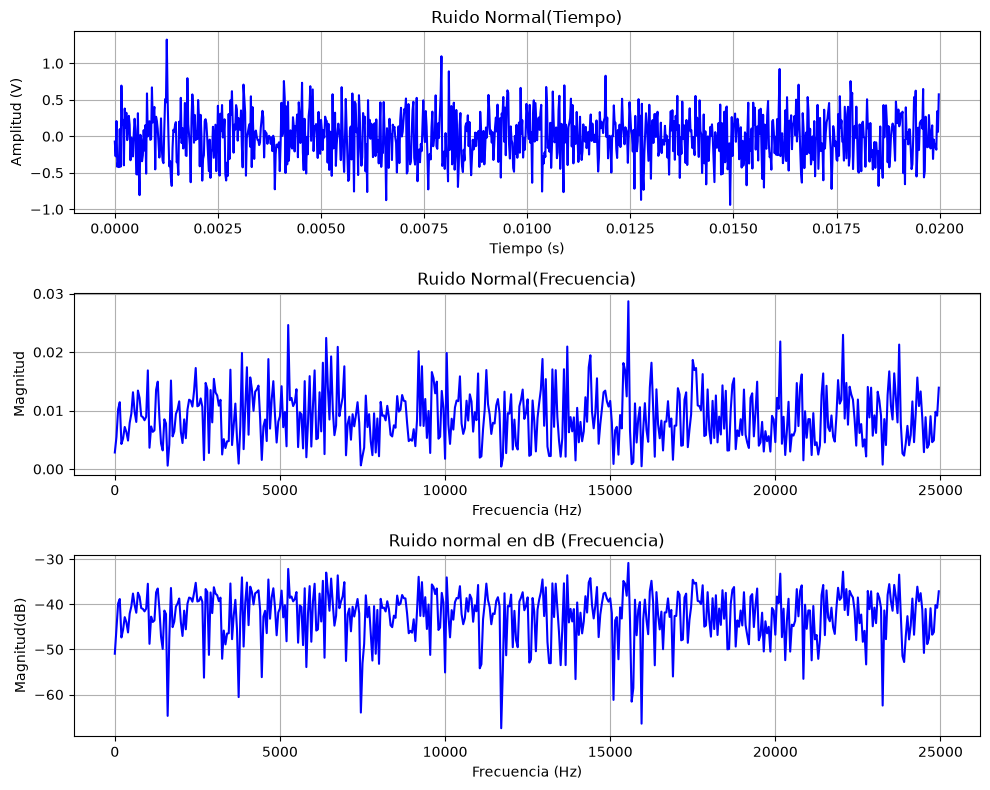

In [40]:

fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(n, ruidonormal, color="blue")
ax[0].set_title("Ruido Normal(Tiempo)")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Amplitud (V)")
ax[0].grid(True)

ax[1].plot(fftx, magrn, color="blue")
ax[1].set_title("Ruido Normal(Frecuencia)")
ax[1].set_xlabel("Frecuencia (Hz)")
ax[1].set_ylabel("Magnitud")
ax[1].grid(True)

ax[2].plot(fftx, magrn_db, color="blue")
ax[2].set_title("Ruido normal en dB (Frecuencia)")
ax[2].set_xlabel("Frecuencia (Hz)")
ax[2].set_ylabel("Magnitud(dB)")
ax[2].grid(True)
plt.tight_layout()
plt.show()


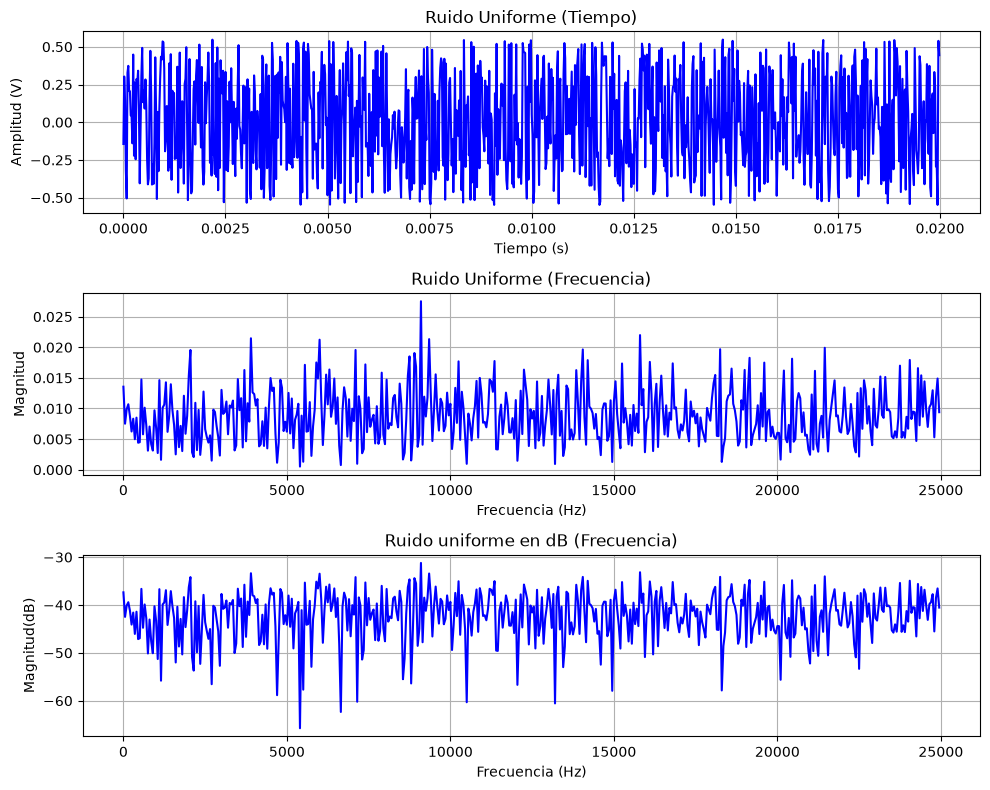

In [41]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(n, ruidouniforme, color="blue")
ax[0].set_title("Ruido Uniforme (Tiempo)")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Amplitud (V)")
ax[0].grid(True)

ax[1].plot(fftx, magru, color="blue")
ax[1].set_title("Ruido Uniforme (Frecuencia)")
ax[1].set_xlabel("Frecuencia (Hz)")
ax[1].set_ylabel("Magnitud")
ax[1].grid(True)

ax[2].plot(fftx, magru_db, color="blue")
ax[2].set_title("Ruido uniforme en dB (Frecuencia)")
ax[2].set_xlabel("Frecuencia (Hz)")
ax[2].set_ylabel("Magnitud(dB)")
ax[2].grid(True)
plt.tight_layout()
plt.show()


Para ambos tipos de ruido su espectro no presenta picos definidos sino que distribuye la energía de forma aproximadamente uniforme en todo el rango de frecuencias

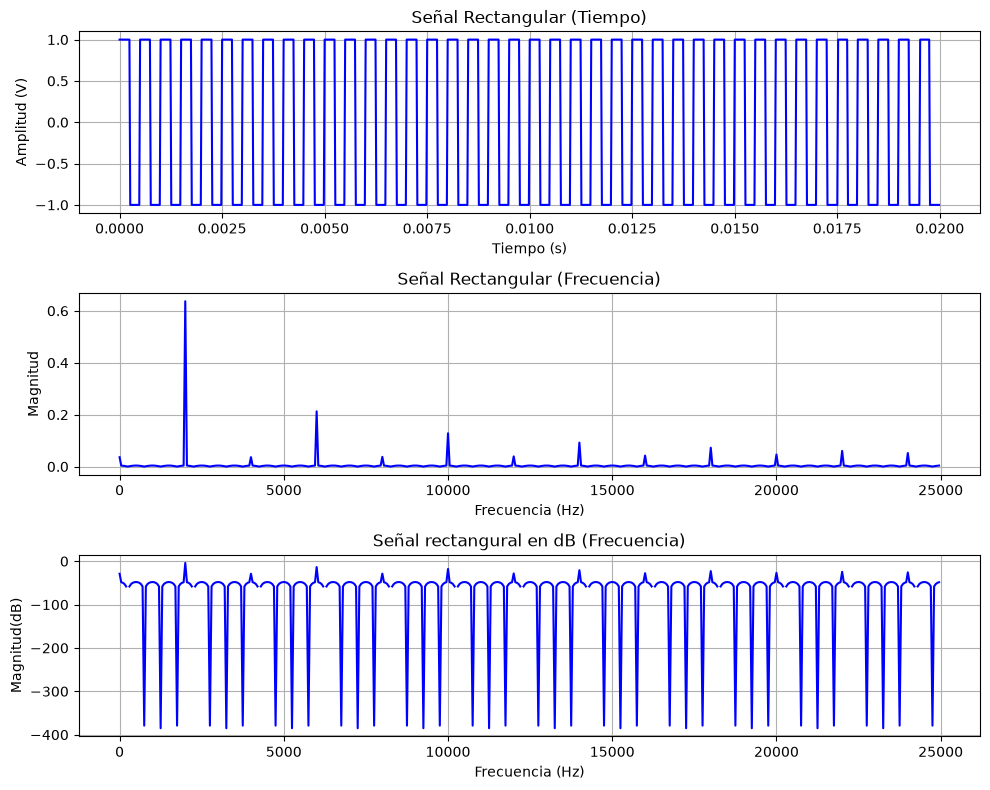

In [42]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8))
ax[0].plot(n, rectangular, color="blue")
ax[0].set_title("Señal Rectangular (Tiempo)")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_ylabel("Amplitud (V)")
ax[0].grid(True)

ax[1].plot(fftx, magsq, color="blue")
ax[1].set_title("Señal Rectangular (Frecuencia)")
ax[1].set_xlabel("Frecuencia (Hz)")
ax[1].set_ylabel("Magnitud")
ax[1].grid(True)

ax[2].plot(fftx, magsq_db, color="blue")
ax[2].set_title("Señal rectangural en dB (Frecuencia)")
ax[2].set_xlabel("Frecuencia (Hz)")
ax[2].set_ylabel("Magnitud(dB)")
ax[2].grid(True)
plt.tight_layout()
plt.show()


El espectro presenta picos únicamente en los armónicos impares de la frecuencia fundamental , con magnitud decreciente proporcional a $$\frac{1}{k}$$
, como se planteo anteriormente. En la escala en dB se observan minimos profundos debido a los ceros exactos de los armónicos pares.

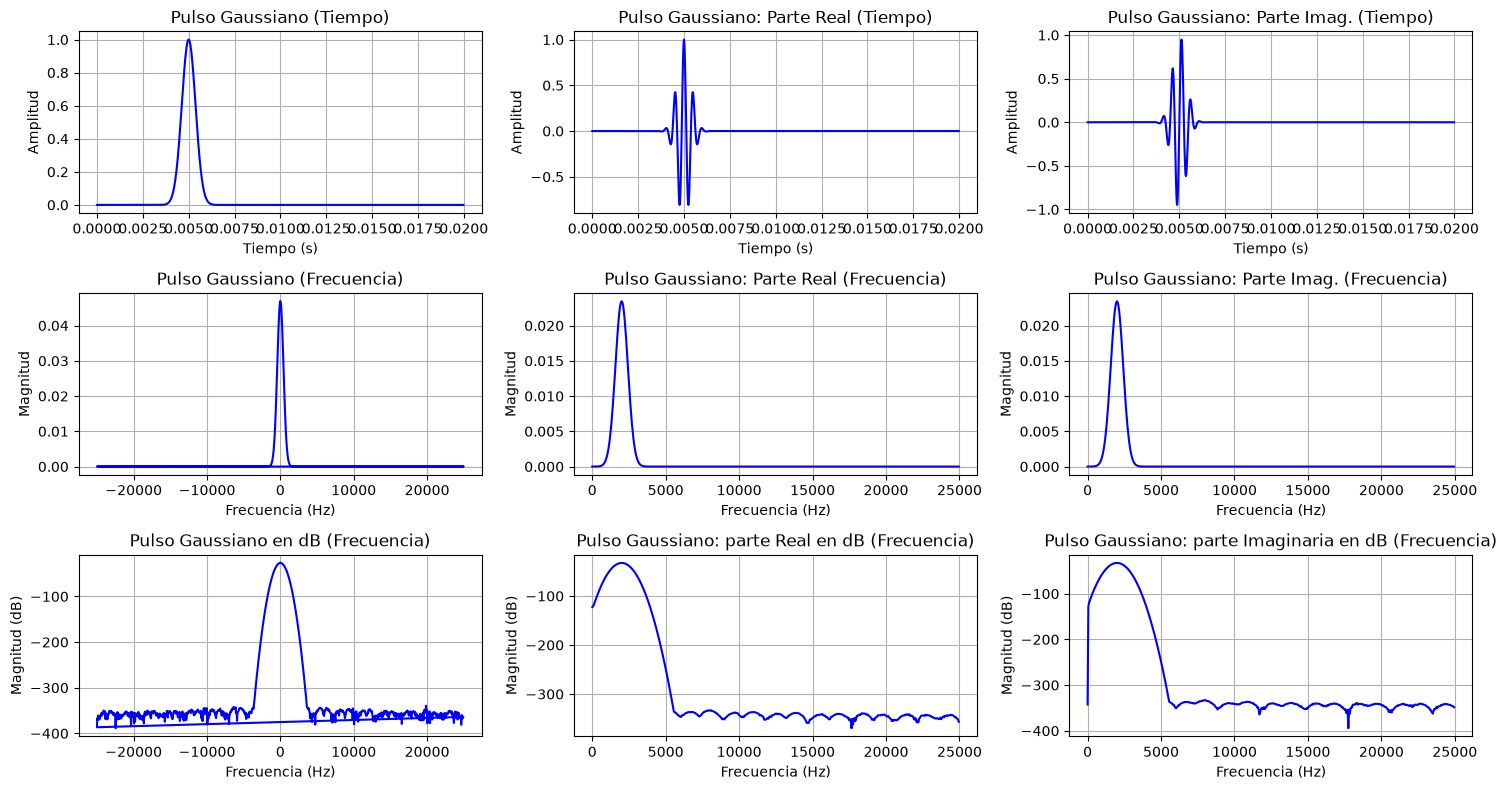

In [43]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))
ax[0, 0].plot(n, gaussiana, color="blue")
ax[0, 0].set_title("Pulso Gaussiano (Tiempo)")
ax[0, 0].set_xlabel("Tiempo (s)")
ax[0, 0].set_ylabel("Amplitud")
ax[0, 0].grid(True)

ax[1, 0].plot(fftxg, magg, color="blue")
ax[1, 0].set_title("Pulso Gaussiano (Frecuencia)")
ax[1, 0].set_xlabel("Frecuencia (Hz)")
ax[1, 0].set_ylabel("Magnitud")
ax[1, 0].grid(True)

ax[2, 0].plot(fftxg, magg_db, color="blue")
ax[2, 0].set_title("Pulso Gaussiano en dB (Frecuencia)")
ax[2, 0].set_xlabel("Frecuencia (Hz)")
ax[2, 0].set_ylabel("Magnitud (dB)")
ax[2, 0].grid(True)


ax[0, 1].plot(n, gaussianareal, color="blue")
ax[0, 1].set_title("Pulso Gaussiano: Parte Real (Tiempo)")
ax[0, 1].set_xlabel("Tiempo (s)")
ax[0, 1].set_ylabel("Amplitud")
ax[0, 1].grid(True)

ax[1, 1].plot(fftx, maggr, color="blue")
ax[1, 1].set_title("Pulso Gaussiano: Parte Real (Frecuencia)")
ax[1, 1].set_xlabel("Frecuencia (Hz)")
ax[1, 1].set_ylabel("Magnitud")
ax[1, 1].grid(True)

ax[2, 1].plot(fftx, maggr_db, color="blue")
ax[2, 1].set_title("Pulso Gaussiano: parte Real en dB (Frecuencia)")
ax[2, 1].set_xlabel("Frecuencia (Hz)")
ax[2, 1].set_ylabel("Magnitud (dB)")
ax[2, 1].grid(True)


ax[0, 2].plot(n, gaussianaimaginaria, color="blue")
ax[0, 2].set_title("Pulso Gaussiano: Parte Imag. (Tiempo)")
ax[0, 2].set_xlabel("Tiempo (s)")
ax[0, 2].set_ylabel("Amplitud")
ax[0, 2].grid(True)

ax[1, 2].plot(fftx, maggi, color="blue")
ax[1, 2].set_title("Pulso Gaussiano: Parte Imag. (Frecuencia)")
ax[1, 2].set_xlabel("Frecuencia (Hz)")
ax[1, 2].set_ylabel("Magnitud")
ax[1, 2].grid(True)

ax[2, 2].plot(fftx, maggi_db, color="blue")
ax[2, 2].set_title("Pulso Gaussiano: parte Imaginaria en dB (Frecuencia)")
ax[2, 2].set_xlabel("Frecuencia (Hz)")
ax[2, 2].set_ylabel("Magnitud (dB)")
ax[2, 2].grid(True)

plt.tight_layout()
plt.show()

La envolvente del pulso, al ser una campana gaussiana en el tiempo, produce un espectro también gaussiano centrado en 0 Hz, sin desplazamiento en frecuencia por tratarse de una señal no modulada. En cambio, las partes real e imaginaria del pulso, que se dan al modular dicha envolvente con un coseno y seno respectivamente, a f=2000 Hz presentan un espectro con la misma forma pero desplazado a 2000 Hz. 

CONCLUSIÓN

En base a estas experiencias se pudoobservar el comportamiento de distintos tipos de señales en el dominio de la frecuancia al aplicar la transformada de Fourier. Las señales periódicas concentran su energía en frecuencias puntuales coincidentes con su frecuencia en el dominio temporal, con amplitudes coincidentes con las obtenidas analíticamente mediante el desarrollo en serie de Fourier. Las señales aleatorias (ruido normal y uniforme), en cambio, distribuyen su energía de manera uniforme en todo el espectro, sin picos puntuales. El pulso gaussiano, por su parte, permitió visualizar  el efecto de la modulación como desplazamiento en frecuencia. Asimismo, el uso de la escala logarítmica (dB) resultó permitió visualizar componentes espectrales de magnitudes muy diferentes dentro de un mismo gráfico.